In [4]:
import sys, site

USER_SITE = site.getusersitepackages()
if USER_SITE not in sys.path:
    sys.path.insert(0, USER_SITE)

import peft
print("PEFT loaded:", peft.__version__)

PEFT loaded: 0.19.1


In [1]:
from datasets import load_dataset

dataset = load_dataset("nyu-mll/glue", "cola")

print(dataset)

cola/train-00000-of-00001.parquet:   0%|          | 0.00/251k [00:00<?, ?B/s]

cola/validation-00000-of-00001.parquet:   0%|          | 0.00/37.6k [00:00<?, ?B/s]

cola/test-00000-of-00001.parquet:   0%|          | 0.00/37.7k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8551 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1043 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1063 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 8551
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1043
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1063
    })
})


In [2]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize, batched=True)

tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print("Tokenization done")

Map:   0%|          | 0/8551 [00:00<?, ? examples/s]

Map:   0%|          | 0/1043 [00:00<?, ? examples/s]

Map:   0%|          | 0/1063 [00:00<?, ? examples/s]

Tokenization done


In [5]:
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query", "value"]
)

model = get_peft_model(model, lora_config)
model.to("cuda")

model.print_trainable_parameters()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 887,042 || all params: 125,534,212 || trainable%: 0.7066


In [6]:
import numpy as np
from sklearn.metrics import matthews_corrcoef

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    mcc = matthews_corrcoef(labels, preds)

    return {
        "mcc": mcc
    }

In [8]:
from pathlib import Path
from transformers import TrainingArguments

BASE = Path.home() / "MyWork" / "LoRA_Reproduction"

training_args = TrainingArguments(
    output_dir=str(BASE / "nlu" / "cola" / "output"),

    learning_rate=5e-4,
    num_train_epochs=10,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=10,

    load_best_model_at_end=True,
    metric_for_best_model="mcc",   # ❗ IMPORTANT
    greater_is_better=True,

    report_to="none"
)

In [9]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

print("Trainer ready")

Trainer ready


In [10]:
model.config.use_cache = False
trainer.train()

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Mcc
1,0.437397,0.454661,0.507275
2,0.347252,0.445555,0.580551
3,0.374769,0.462222,0.600624
4,0.359625,0.551292,0.578920
5,0.246431,0.453616,0.610872
6,0.185573,0.511936,0.605659
7,0.187145,0.522960,0.613238
8,0.255186,0.591823,0.577848
9,0.198671,0.642318,0.593084
10,0.162190,0.666951,0.595815


TrainOutput(global_step=5350, training_loss=0.2859245137967796, metrics={'train_runtime': 294.1427, 'train_samples_per_second': 290.709, 'train_steps_per_second': 18.188, 'total_flos': 5682910124328960.0, 'train_loss': 0.2859245137967796, 'epoch': 10.0})

In [11]:
import json

results = {
    "task": "CoLA",
    "metric": "MCC",
    "value": float(trainer.evaluate()["eval_mcc"])
}

LOGS_DIR = BASE / "results" / "logs"

with open(LOGS_DIR / "cola_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("CoLA saved!")

Training Loss,Validation Loss,Epoch,Mcc
0.162190,0.522960,10,0.613238


CoLA saved!


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import json

# Save results relative to the current notebook folder.
RESULTS_DIR = Path.cwd() / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Values copied from the completed CoLA training output.
epochs = list(range(1, 11))

training_loss = [
    0.437397,
    0.347252,
    0.374769,
    0.359625,
    0.246431,
    0.185573,
    0.187145,
    0.255186,
    0.198671,
    0.162190,
]

validation_loss = [
    0.454661,
    0.445555,
    0.462222,
    0.551292,
    0.453616,
    0.511936,
    0.522960,
    0.591823,
    0.642318,
    0.666951,
]

mcc_scores = [
    0.507275,
    0.580551,
    0.600624,
    0.578920,
    0.610872,
    0.605659,
    0.613238,
    0.577848,
    0.593084,
    0.595815,
]

results_df = pd.DataFrame({
    "epoch": epochs,
    "training_loss": training_loss,
    "validation_loss": validation_loss,
    "validation_mcc": mcc_scores,
})

display(results_df)

,epoch,training_loss,validation_loss,validation_mcc
0,1,0.437397,0.454661,0.507275
1,2,0.347252,0.445555,0.580551
2,3,0.374769,0.462222,0.600624
3,4,0.359625,0.551292,0.578920
4,5,0.246431,0.453616,0.610872
5,6,0.185573,0.511936,0.605659
6,7,0.187145,0.522960,0.613238
7,8,0.255186,0.591823,0.577848
8,9,0.198671,0.642318,0.593084
9,10,0.162190,0.666951,0.595815


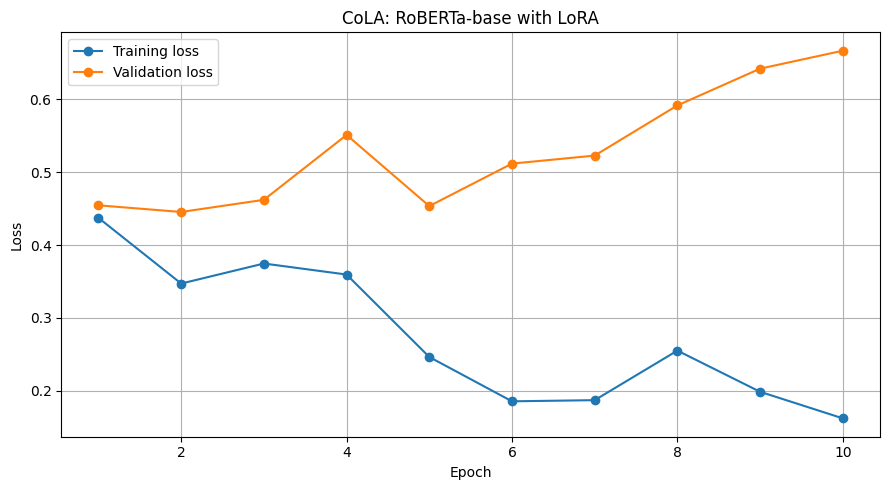

Saved: /projects/nn-bsc/shahd.baloum/project/notebooks/results/cola_loss_curve.png


In [3]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    training_loss,
    marker="o",
    label="Training loss",
)

plt.plot(
    epochs,
    validation_loss,
    marker="o",
    label="Validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CoLA: RoBERTa-base with LoRA")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_plot_path = RESULTS_DIR / "cola_loss_curve.png"

plt.savefig(
    loss_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", loss_plot_path)

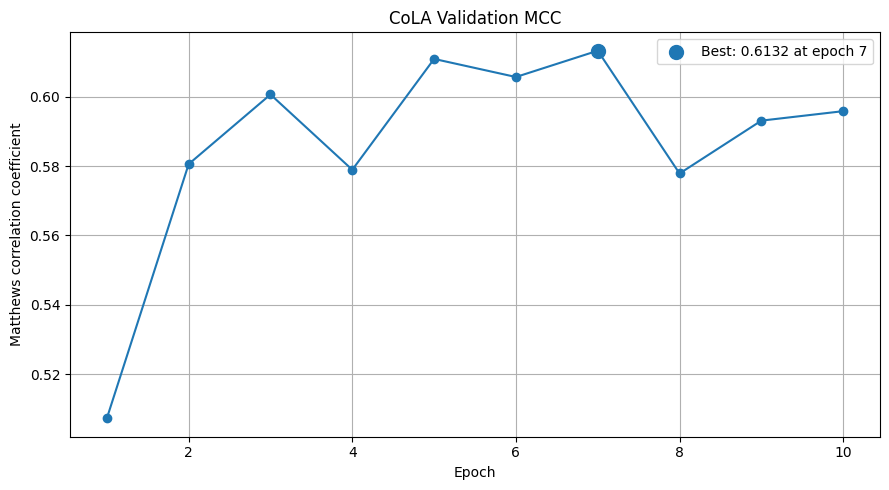

Saved: /projects/nn-bsc/shahd.baloum/project/notebooks/results/cola_mcc_curve.png


In [4]:
plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    mcc_scores,
    marker="o",
)

best_epoch = epochs[mcc_scores.index(max(mcc_scores))]
best_mcc = max(mcc_scores)

plt.scatter(
    [best_epoch],
    [best_mcc],
    s=100,
    label=f"Best: {best_mcc:.4f} at epoch {best_epoch}",
)

plt.xlabel("Epoch")
plt.ylabel("Matthews correlation coefficient")
plt.title("CoLA Validation MCC")
plt.legend()
plt.grid(True)
plt.tight_layout()

mcc_plot_path = RESULTS_DIR / "cola_mcc_curve.png"

plt.savefig(
    mcc_plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", mcc_plot_path)

In [5]:
cola_results = {
    "task": "CoLA",
    "model": "roberta-base",
    "method": "LoRA",
    "metric": "Matthews correlation coefficient",
    "best_validation_mcc": best_mcc,
    "best_epoch": best_epoch,
    "final_epoch_mcc": mcc_scores[-1],
    "best_validation_loss": min(validation_loss),
    "num_train_epochs": 10,
    "learning_rate": 5e-4,
    "lora_rank": 8,
    "lora_alpha": 16,
    "target_modules": ["query", "value"],
    "trainable_parameters": 887042,
    "trainable_percentage": 0.7066,
}

metrics_path = RESULTS_DIR / "cola_results.json"

with metrics_path.open("w", encoding="utf-8") as file:
    json.dump(
        cola_results,
        file,
        indent=2,
    )

results_df.to_csv(
    RESULTS_DIR / "cola_epoch_history.csv",
    index=False,
)

print("Saved:", metrics_path)

Saved: /projects/nn-bsc/shahd.baloum/project/notebooks/results/cola_results.json
